# Strategy Project - CFRM 522
## Trend-Filtered Drawdown Control Strategy
### Jackson Wang


## Summary

This project studies a defensive trading overlay that combines a moving-average trend filter with an equity-curve drawdown control rule. The trend component classifies the market as risk-on or risk-off based on whether price is above or below a moving average with lookback $M \in \{60, 120, 240\}$.

The drawdown component monitors the strategy equity curve and triggers a cooling-off period when drawdown reaches a chosen threshold $d^* \in \{10\%, 15\%, 20\%\}$. The main idea is to reduce exposure during unfavorable market conditions and after meaningful losses, with the goal of improving downside protection relative to a passive alternative.


## Constraints, Benchmarks, and Objectives
### Constraints
1. Data: I used only information available at the decision time (no look-ahead). Strategy is tested on liquid instruments and easily accessible daily close market data, such as ETFs and futures, to ensure realistic execution.
2. Transaction Cost: All reported results include a fixed transaction cost.
3. Parameters: Parameter choices are kept small and interpretable. Only a limited grid is tested to reduce overfitting risk and simplifying test, and the same parameter set is used consistently in out-of-sample evaluation unless a walk-forward procedure is applied.

# Benchmarks
Buy-and hold benchmark of the same asset.

# Objectives
Primary objective: The strategy aims to reduce the severity of drawdowns and potentially shorten drawdown duration by lowering exposure during weak market regimes and after losses.

Secondary objective: Evaluate whether these downside improvements can be achieved without giving up too much long-run return.

The main dependent variables are annualized return, annualized volatility, Sharpe ratio, maximum drawdown, drawdown duration, and Calmar ratio.

## Hypotheses
### 1. H1:
A trend-filtered drawdown-control strategy is expected to produce shallower drawdowns than a passive benchmark.

Expected outcome: Lower MDD

### H2:
The strategy is expected to improve downside risk-adjusted performance, though possibly at the cost of lower absolute return in strong bull markets.

Expected outcome: Return and Sharpe ratio may drop slightly, but Calmar ratio improves.
### H3:
The strategy may shorten recovery periods following losses by reducing exposure during adverse market conditions.

Expected outcome: Potentially shorter drawdown duration

### H4:
Drawdown improvements remain present in OOS testing, not only in-sample.

Expected outcome: OOS deterioration is limited and the overlay still improves drawdown metrics.

## Strategy

### Data
The tests use daily bar data for liquid funds(ETFs). The primary experiment focuses on SPY and QQQ to provide a clean comparison between a baseline trend strategy and the same strategy augmented with a drawdown-control overlay. An extension universe (EEM, IWM, TLT, GLD, and BTC) is used to evaluate whether the overlay's drawdown effects generalize beyond large-cap U.S. equities and remain stable across different market characteristics and regimes. SPY and QQQ would use the different time period than primary experiment for out-of-sample validation.


### Filter
I would use liquidity filter to ensure that the strategy is evaluated only on instruments that are liquid, tradeable, and have sufficient historical data to compute the strategy's indicators over the full test window.

### Indicators
This strategy uses two indicators computed from daily market data.
1. Trend Indicator:
Using moving-average crossover to identify the persistent directional movement in the instrument.

$$\text{Trend}_t = \frac{P_t}{\text{MA}_{M,t}} - 1$$

where:
* $P_t$ = price at time $t$

* $\text{MA}_{M,t}$ = $M$-day moving average $M\in \{60, 120, 240\}$

* $\text{Trend}_t > 0$: upward trend
* $\text{Trend}_t < 0$: downward trend

Forward Returns: To validate indicators and convert each indicator into groups for comparison

$$R_{t,h} = \frac{P_{t+h}}{P_t} - 1, \quad h \in \{1, 5, 20\}$$

2. Equity - Curve Drawdown Indicator: An equity-curve drawdown indicator that measures how far the strategy equity curve is below its historical peak.

$$M_t = \max(E_0, E_1, \dots, E_t)$$

$$DD_t = \frac{E_t - M_t}{M_t}$$
Interpretation:
* $DD_t = 0$: at a new peak
* $DD_t < 0$: below peak

### Indicator Evaluation

This code performs indicator-only tests for SPY and QQQ using daily Yahoo Finance data.

First, it downloads adjusted daily prices for SPY and QQQ and computes daily returns plus 1-day, 5-day, and 20-day forward returns. These forward returns are used to evaluate whether the indicators help distinguish better future market conditions from worse ones and to validate indicators and convert each indicator into groups for comparison.

Second, it tests the trend indicator by comparing future returns when price is above the moving average versus when price is below the moving average, for lookback windows of 60, 120, and 240 trading days. The goal is to see whether the trend state separates stronger forward returns from weaker ones.

Third, it tests the drawdown indicator by constructing a buy-and-hold equity curve, computing its drawdown, and then comparing future returns when drawdown has breached a threshold versus when it has not. The thresholds tested are 10%, 15%, and 20%. The goal is to see whether drawdown states are associated with weaker subsequent performance.

In [271]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["SPY", "QQQ"]

start_date = "2010-01-01"
end_date   = "2025-12-31"

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
prices = prices.dropna()
prices.tail()

[*********************100%***********************]  2 of 2 completed


Ticker,QQQ,SPY
Date,,
2025-12-23,622.109985,687.960022
2025-12-24,623.929993,690.380005
2025-12-26,623.890015,690.309998
2025-12-29,620.869995,687.849976
2025-12-30,619.429993,687.010010


In [272]:
def prepare_data(price_series):
    df = pd.DataFrame({"Close": price_series}).dropna().copy()
    df["ret_1d"] = df["Close"].pct_change()
    df["fwd_ret_1d"] = df["Close"].shift(-1) / df["Close"] - 1
    df["fwd_ret_5d"] = df["Close"].shift(-5) / df["Close"] - 1
    df["fwd_ret_20d"] = df["Close"].shift(-20) / df["Close"] - 1
    return df

In [273]:
def trend_indicator_test(df, M_list=[60, 120, 240]):
    results = []

    for M in M_list:
        temp = df.copy()
        temp[f"MA_{M}"] = temp["Close"].rolling(M).mean()
        temp["trend_signal"] = np.where(temp["Close"] > temp[f"MA_{M}"], 1, 0)

        for h in [1, 5, 20]:
            fwd_col = f"fwd_ret_{h}d"
            valid = temp.dropna(subset=[f"MA_{M}", fwd_col])

            summary = valid.groupby("trend_signal")[fwd_col].agg(["mean", "std", "count"])
            summary["hit_rate"] = valid.groupby("trend_signal")[fwd_col].apply(lambda x: (x > 0).mean())

            summary["M"] = M
            summary["horizon"] = h
            results.append(summary.reset_index())

    return pd.concat(results, ignore_index=True)

In [274]:
spy = prepare_data(prices["SPY"])
qqq = prepare_data(prices["QQQ"])

spy_trend_test = trend_indicator_test(spy)
qqq_trend_test = trend_indicator_test(qqq)

print("SPY Trend Indicator Test")
display(spy_trend_test)

print("QQQ Trend Indicator Test")
display(qqq_trend_test)

SPY Trend Indicator Test


,trend_signal,mean,std,count,hit_rate,M,horizon
0,0,0.001154,0.016982,988,0.564777,60,1
1,1,0.000385,0.007843,2975,0.548571,60,1
2,0,0.005276,0.033807,988,0.620445,60,5
3,1,0.002036,0.017080,2971,0.610905,60,5
4,0,0.020998,0.054260,987,0.701114,60,20
5,1,0.007954,0.036094,2957,0.682787,60,20
6,0,0.001220,0.018456,755,0.549669,120,1
7,1,0.000458,0.007900,3148,0.554320,120,1
8,0,0.006034,0.036031,755,0.618543,120,5
9,1,0.002286,0.017413,3144,0.615776,120,5


QQQ Trend Indicator Test


,trend_signal,mean,std,count,hit_rate,M,horizon
0,0,0.001444,0.019193,1051,0.552807,60,1
1,1,0.000518,0.009924,2912,0.559753,60,1
2,0,0.007007,0.036972,1051,0.619410,60,5
3,1,0.002602,0.022119,2908,0.603508,60,5
4,0,0.028466,0.060572,1048,0.726145,60,20
5,1,0.010004,0.045250,2896,0.662293,60,20
6,0,0.001575,0.020686,761,0.547963,120,1
7,1,0.000600,0.010285,3142,0.561744,120,1
8,0,0.007332,0.039134,761,0.624179,120,5
9,1,0.003103,0.022724,3138,0.606119,120,5


For both SPY and QQQ, when trend_signal = 0 (price below the moving average), the subsequent mean returns are often higher than when trend_signal = 1 (price above the moving average), especially at the 5-day and 20-day horizons.

In [275]:
def drawdown_indicator_test(df, d_list=[0.10, 0.15, 0.20]):
    temp = df.copy()

    temp["equity"] = (1 + temp["ret_1d"].fillna(0)).cumprod()
    temp["peak"] = temp["equity"].cummax()
    temp["drawdown"] = (temp["equity"] - temp["peak"]) / temp["peak"]

    results = []

    for d in d_list:
        temp2 = temp.copy()
        temp2["dd_signal"] = np.where(temp2["drawdown"] > -d, 1, 0)

        for h in [1, 5, 20]:
            fwd_col = f"fwd_ret_{h}d"
            valid = temp2.dropna(subset=["drawdown", fwd_col])

            summary = valid.groupby("dd_signal")[fwd_col].agg(["mean", "std", "count"])
            summary["hit_rate"] = valid.groupby("dd_signal")[fwd_col].apply(lambda x: (x > 0).mean())

            summary["threshold"] = d
            summary["horizon"] = h
            results.append(summary.reset_index())

    return pd.concat(results, ignore_index=True)

In [276]:
spy_dd_test = drawdown_indicator_test(spy)
qqq_dd_test = drawdown_indicator_test(qqq)

print("SPY Drawdown Indicator Test")
display(spy_dd_test)

print("QQQ Drawdown Indicator Test")
display(qqq_dd_test)

SPY Drawdown Indicator Test


,dd_signal,mean,std,count,hit_rate,threshold,horizon
0,0,0.001658,0.020369,507,0.528600,0.10,1
1,1,0.000423,0.008635,3515,0.557895,0.10,1
2,0,0.007909,0.037031,507,0.613412,0.10,5
3,1,0.002125,0.019370,3511,0.614640,0.10,5
4,0,0.028794,0.058548,507,0.710059,0.10,20
5,1,0.008888,0.038152,3496,0.685641,0.10,20
6,0,0.003647,0.023691,220,0.536364,0.15,1
7,1,0.000401,0.009562,3802,0.555234,0.15,1
8,0,0.014027,0.039412,220,0.640909,0.15,5
9,1,0.002208,0.020887,3798,0.612954,0.15,5


QQQ Drawdown Indicator Test


,dd_signal,mean,std,count,hit_rate,threshold,horizon
0,0,0.002583,0.021901,623,0.563403,0.10,1
1,1,0.000431,0.010565,3399,0.558400,0.10,1
2,0,0.009772,0.041414,623,0.648475,0.10,5
3,1,0.002675,0.023074,3395,0.601178,0.10,5
4,0,0.028182,0.073786,623,0.669342,0.10,20
5,1,0.012733,0.044480,3380,0.682249,0.10,20
6,0,0.001628,0.023714,356,0.505618,0.15,1
7,1,0.000680,0.011446,3666,0.564375,0.15,1
8,0,0.007954,0.042536,356,0.612360,0.15,5
9,1,0.003369,0.024798,3662,0.608138,0.15,5


The drawdown results show a very similar pattern. When dd_signal = 0 meaning a drawdown breach has occurred, future returns are often higher, not lower.

For both SPY and QQQ, the trend and drawdown indicators do not appear to predict weaker forward returns in isolation. In many cases, below-moving-average states and drawdown-breach states are followed by stronger 5-day and 20-day returns, suggesting rebound or mean-reversion effects rather than continuation.

I also found that the SPY's rebound is much greater than that of QQQ. Historically, whenever the SPY falls by more than 20%, it almost always rebounds within the next 20 trading days (a hit rate of approximately 92.8%). In contrast, QQQ's performance is relatively weak after falling by more than 20%. QQQ also experiences more pullbacks exceeding 20% than SPY, with QQQ having 260 trading days compared to the SPY's 56.

### Signals
1. Trend Signal   

$$T_t = \begin{cases} 1, & P_t > \text{MA}_{M,t} \\ 0, & P_t \le \text{MA}_{M,t} \end{cases}$$

where

$$M \in \{60, 120, 240\}.$$

where 1 indicates a positive (risk-on) trend state and 0 indicates a negative (risk-off) trend state.


2. Drawdown Trigger Signal       
$$D_t = \begin{cases} 1, & DD_t > -d^* \\ 0, & DD_t \le -d^* \end{cases}$$

where

$$d^* \in \{10\%, 15\%, 20\%\}$$

where 1 indicates no drawdown breach and 0 indicates that the 10%/15%/20% drawdown threshold has been breached.

### Signals Evaluation
This step is to convert the raw indicators into simple binary signals that can later be used in the trading rules. For the trend indicator, the code assigns a value of 1 when the ETF price is above the moving average and 0 otherwise, which identifies whether the market is in a risk-on or risk-off state. For the drawdown indicator, the code assigns a value of 1 when the current drawdown has not breached the chosen threshold and 0 when the threshold has been breached. These signals are created separately for SPY and QQQ and for all tested parameter values so that they can be used consistently in the later rule and strategy sections.

In [277]:
def build_signals(price_series):
    df = pd.DataFrame({"Close": price_series}).dropna().copy()
    df["daily_ret"] = df["Close"].pct_change()

    # trend signals
    for M in [60, 120, 240]:
        df[f"MA_{M}"] = df["Close"].rolling(M).mean()
        df[f"trend_signal_{M}"] = np.where(df["Close"] > df[f"MA_{M}"], 1, 0)

    # drawdown and drawdown signals
    df["equity"] = (1 + df["daily_ret"].fillna(0)).cumprod()
    df["peak"] = df["equity"].cummax()
    df["drawdown"] = (df["equity"] - df["peak"]) / df["peak"]

    for d in [0.10, 0.15, 0.20]:
        df[f"dd_signal_{int(d*100)}"] = np.where(df["drawdown"] > -d, 1, 0)

    return df

spy = build_signals(prices["SPY"])
qqq = build_signals(prices["QQQ"])

spy.tail()

,Close,daily_ret,MA_60,trend_signal_60,MA_120,trend_signal_120,MA_240,trend_signal_240,equity,peak,drawdown,dd_signal_10,dd_signal_15,dd_signal_20
Date,,,,,,,,,,,,,,
2025-12-23,687.960022,0.004570,672.868034,1,655.512846,1,615.064981,1,8.090986,8.090986,0.000000,1,1,1
2025-12-24,690.380005,0.003518,673.304079,1,656.123177,1,615.550930,1,8.119447,8.119447,0.000000,1,1,1
2025-12-26,690.309998,-0.000101,673.701235,1,656.735740,1,616.032880,1,8.118624,8.119447,-0.000101,1,1,1
2025-12-29,687.849976,-0.003564,674.044596,1,657.296981,1,616.501286,1,8.089692,8.119447,-0.003665,1,1,1
2025-12-30,687.010010,-0.001221,674.374123,1,657.836639,1,616.922579,1,8.079813,8.119447,-0.004881,1,1,1


In [278]:
qqq.tail()

,Close,daily_ret,MA_60,trend_signal_60,MA_120,trend_signal_120,MA_240,trend_signal_240,equity,peak,drawdown,dd_signal_10,dd_signal_15,dd_signal_20
Date,,,,,,,,,,,,,,
2025-12-23,622.109985,0.004683,612.075890,1,591.988236,1,546.589376,1,15.421059,15.73939,-0.020225,1,1,1
2025-12-24,623.929993,0.002926,612.481432,1,592.598642,1,547.086456,1,15.466174,15.73939,-0.017359,1,1,1
2025-12-26,623.890015,-0.000064,612.838370,1,593.206138,1,547.590127,1,15.465183,15.73939,-0.017422,1,1,1
2025-12-29,620.869995,-0.004841,613.103694,1,593.755963,1,548.083205,1,15.390322,15.73939,-0.022178,1,1,1
2025-12-30,619.429993,-0.002319,613.387462,1,594.300438,1,548.522110,1,15.354626,15.73939,-0.024446,1,1,1


### Rules
1. Use the trend signal to determine whether the strategy is risk-on or risk-off.
2. Use the drawdown signal to determine whether a drawdown breach has occurred at threshold
$d^*$.
3. If a drawdown breach occurs, apply the corresponding cooldown period C and exposure level.

* If $T_t = 0$, move to risk-off.
* If $T_t = 1$ and $D_t = 1$, remain at normal exposure.
* If $T_t = 1$ and $D_t = 0$, activate the cooldown period and exposure level associated with the chosen drawdown threshold.

$$C(d^*) = \begin{cases} 5, & d^* = 10\%, & 50\% exposure\\ 10, & d^* = 15\%, & 20\% exposure \\ 20, & d^* = 20\%, & 0\% exposure \end{cases}$$


### Rules Evaluation
This step combines the binary trend and drawdown signals into rule-based states that can later be used in the strategy. When the trend signal is positive, the strategy remains fully invested unless a drawdown threshold is breached. A 10% breach triggers 50% exposure for 5 trading days, a 15% breach triggers 20% exposure for 10 trading days, and a 20% breach triggers 0% exposure for 20 trading days. If the trend signal turns negative, the strategy moves fully out of the market regardless of drawdown state.

In [279]:
def build_rule_with_cooldown(df, M):
    n = len(df)
    exposure = np.ones(n)

    cooldown_days_left = 0
    cooldown_exposure = 1.0

    drawdown_values = df["drawdown"].values
    trend_values = df[f"trend_signal_{M}"].values

    for i in range(n):
        if trend_values[i] == 0:
            exposure[i] = 0
            cooldown_days_left = 0
            cooldown_exposure = 1.0
            continue


        if cooldown_days_left > 0:
            new_dd = drawdown_values[i]

            if new_dd <= -0.20 and cooldown_exposure > 0.0:
                cooldown_exposure = 0.0
                cooldown_days_left = 20 - 1
            elif new_dd <= -0.15 and cooldown_exposure > 0.2:
                cooldown_exposure = 0.2
                cooldown_days_left = 10 - 1

            exposure[i] = cooldown_exposure
            cooldown_days_left -= 1
            continue

        dd = drawdown_values[i]

        if dd <= -0.20:
            cooldown_exposure = 0.0
            cooldown_days_left = 20 - 1
            exposure[i] = 0.0

        elif dd <= -0.15:
            cooldown_exposure = 0.2
            cooldown_days_left = 10 - 1
            exposure[i] = 0.2

        elif dd <= -0.10:
            cooldown_exposure = 0.5
            cooldown_days_left = 5 - 1
            exposure[i] = 0.5

        else:
            exposure[i] = 1.0

    df[f"rule_{M}"] = exposure
    return df

In [280]:
for M in [60, 120, 240]:
    spy = build_rule_with_cooldown(spy, M)
    qqq = build_rule_with_cooldown(qqq, M)

In [281]:
test_slice = qqq[(qqq[f"rule_120"] < 1) & (qqq["trend_signal_120"] == 1)].head(15)
print(test_slice[["Close", "drawdown", "trend_signal_120", "rule_120"]])


                 Close  drawdown  trend_signal_120  rule_120
Date                                                        
2018-02-08  145.628448 -0.102264                 1       0.5
2018-02-09  148.143387 -0.086761                 1       0.5
2018-02-12  150.772171 -0.070555                 1       0.5
2018-02-13  151.550385 -0.065758                 1       0.5
2018-02-14  154.388031 -0.048265                 1       0.5
2020-03-03  202.134445 -0.116044                 1       0.5
2020-03-04  210.567963 -0.079163                 1       0.5
2020-03-05  204.170486 -0.107140                 1       0.5
2020-03-06  200.725662 -0.122204                 1       0.5
2020-04-14  204.866638 -0.104095                 1       0.5
2020-04-15  202.516846 -0.114371                 1       0.5
2020-04-16  206.210800 -0.098217                 1       0.5
2020-04-17  208.183441 -0.089591                 1       0.5
2020-04-20  205.717651 -0.100374                 1       0.5
2020-04-22  204.006027 -

### Initial parameter choices
1. Trend lookback window M is tested on $$M \in \{60, 120, 240\}$$
2. Drawdown threshold
$$d^* \in \{10\%, 15\%, 20\%\}$$

3. Cooldown length $$C \in \{5, 10, 20\}$$

A 5-day cooling-off period and 50% exposure will be implemented when the drawdown exceeds 10%; A 10-day cooling-off period and 20% exposure will be implemented when the drawdown exceeds 15%; A 20-day cooling-off period and 0% exposure will be implemented when the drawdown exceeds 20%.

# Optimization of parameters


This section evaluates parameter optimization for the full trading system by comparing the three moving-average lookback choices $M\in \{60, 120, 240\}$. I used the Calmar ratio as the primary objective function, since it directly reflects the tradeoff between annualized return and maximum drawdown. To reduce overfitting risk and limits the degrees of freedom, the drawdown thresholds, exposure reductions, and cooldown lengths are fixed by the strategy design.

In [282]:
def add_strategy_returns(df, M):
    temp = df.copy()
    if f"rule_{M}" not in temp.columns:
        temp = build_rule_with_cooldown(temp, M)

    temp["position"] = temp[f"rule_{M}"].shift(1).fillna(0)
    temp["strategy_ret"] = temp["position"] * temp["daily_ret"]
    temp["strategy_equity"] = (1 + temp["strategy_ret"].fillna(0)).cumprod()
    return temp
def max_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    dd = equity_curve / running_max - 1
    return dd.min()
def drawdown_duration(equity_curve):
    running_max = equity_curve.cummax()
    dd = equity_curve / running_max - 1

    duration = 0
    max_duration = 0

    for x in dd:
        if x < 0:
            duration += 1
            max_duration = max(max_duration, duration)
        else:
            duration = 0

    return max_duration

In [283]:
def strategy_metrics(df, M):
    temp = df.copy()
    if f"rule_{M}" not in temp.columns:
        temp = build_rule_with_cooldown(temp, M)
    temp = add_strategy_returns(temp, M).dropna().copy()

    n = len(temp)
    if n == 0:
        return None

    ann_return = temp["strategy_equity"].iloc[-1] ** (252 / n) - 1
    ann_vol = temp["strategy_ret"].std() * np.sqrt(252)
    mdd = max_drawdown(temp["strategy_equity"])
    dd_dur = drawdown_duration(temp["strategy_equity"])

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    calmar = ann_return / abs(mdd) if mdd != 0 else np.nan

    return pd.Series({
        "M": M,
        "AnnReturn": ann_return,
        "AnnVol": ann_vol,
        "MaxDD": mdd,
        "MaxDD_Duration": dd_dur,
        "Sharpe": sharpe,
        "Calmar": calmar
    })

In [284]:
def optimize_M(df, M_list=[60, 120, 240], start=None, end=None):
    temp = df.copy()

    if start is not None:
        temp = temp.loc[start:]
    if end is not None:
        temp = temp.loc[:end]

    results = []
    for M in M_list:
        results.append(strategy_metrics(temp, M))

    results = pd.DataFrame(results)
    results = results.sort_values("Calmar", ascending=False).reset_index(drop=True)
    return results

In [285]:
insample_start = "2010-01-01"
insample_end   = "2018-12-31"

oos_start = "2019-01-01"
oos_end   = "2025-12-31"
spy_opt = optimize_M(spy, start=insample_start, end=insample_end)
qqq_opt = optimize_M(qqq, start=insample_start, end=insample_end)

print("SPY In-Sample Parameter Optimization")
display(spy_opt)

print("QQQ In-Sample Parameter Optimization")
display(qqq_opt)

SPY In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,120.0,0.067875,0.104591,-0.150178,488.0,0.648958,0.451964
1,240.0,0.076984,0.113273,-0.198953,462.0,0.679630,0.386946
2,60.0,0.045472,0.096306,-0.167139,736.0,0.472165,0.272063


QQQ In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.091881,0.141996,-0.199211,443.0,0.647068,0.461224
1,120.0,0.088879,0.128174,-0.195144,388.0,0.693421,0.455451
2,60.0,0.072241,0.115079,-0.202029,626.0,0.627748,0.357577


For SPY, the in-sample optimization shows that M = 120 has the best Calmar ratio. Although M = 240 has the highest annualized return and Sharpe ratio, M = 120 has a smaller maximum drawdown and the highest Calmar ratio, which is what my strategy wants to evaluate.

For QQQ, the in-sample optimization shows that M = 240 is the best parameter. It has the highest annualized return and the highest Calmar ratio, while M = 120 is only slightly better on Sharpe ratio.

In [286]:
def test_selected_M(df, M, start=None, end=None):
    temp = df.copy()

    if start is not None:
        temp = temp.loc[start:]
    if end is not None:
        temp = temp.loc[:end]

    return pd.DataFrame([strategy_metrics(temp, M)])

spy_best_M = int(spy_opt.iloc[0]["M"])
qqq_best_M = int(qqq_opt.iloc[0]["M"])

spy_oos = test_selected_M(spy, spy_best_M, start=oos_start, end=oos_end)
qqq_oos = test_selected_M(qqq, qqq_best_M, start=oos_start, end=oos_end)

print("SPY Out-of-Sample Test")
display(spy_oos)

print("QQQ Out-of-Sample Test")
display(qqq_oos)

SPY Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,120.0,0.115445,0.11347,-0.146728,531.0,1.017413,0.786801


QQQ Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.142119,0.153313,-0.197244,546.0,0.926983,0.720523


The out-of-sample tests support these in-sample optimizations reasonably well.
For SPY, the selected M = 120 performs well out of sample with a higher annualized return, lower maximum drawdown, and higher Calmar ratio. The results suggest that the selected parameter did not collapse or overfit out of sample.

For QQQ, the selected M=240 also remains strong out of sample, which also supports the stability of the selected parameter.

I also found that this defensive strategy prefers medium to large scale fluctuations, like those in 2020/2022, rather than the stable and slow-rising market of 2010-2018. Such an outcome is also one of my objectives in this strategy. Furthermore, the drawdown days all exceeded 500 days (approximately 2 years), even as returns increased.


In [287]:
def get_bh_metrics(df, name):
    equity = (1 + df["daily_ret"]).cumprod()
    n_days = len(df)

    ann_ret = equity.iloc[-1]**(252/n_days) - 1

    ann_vol = df["daily_ret"].std() * np.sqrt(252)

    running_max = equity.cummax()
    dd = equity / running_max - 1
    mdd = dd.min()

    duration = 0
    max_dur = 0
    for x in dd:
        if x < 0:
            duration += 1
            max_dur = max(max_dur, duration)
        else:
            duration = 0

    return pd.Series({
        "Strategy": name,
        "AnnReturn": ann_ret,
        "AnnVol": ann_vol,
        "MaxDD": mdd,
        "MaxDD_Duration": max_dur,
        "Sharpe": ann_ret / ann_vol if ann_vol != 0 else np.nan,
        "Calmar": ann_ret / abs(mdd) if mdd != 0 else np.nan
    })

spy_oos_data = spy.loc[oos_start:oos_end]
qqq_oos_data = qqq.loc[oos_start:oos_end]

spy_bh = get_bh_metrics(spy_oos_data, "SPY Buy & Hold")
qqq_bh = get_bh_metrics(qqq_oos_data, "QQQ Buy & Hold")

spy_strat = spy_oos.iloc[0].copy()
spy_strat["Strategy"] = f"SPY Defensive (M={spy_best_M})"

qqq_strat = qqq_oos.iloc[0].copy()
qqq_strat["Strategy"] = f"QQQ Defensive (M={qqq_best_M})"

comparison_table = pd.DataFrame([
    spy_strat, spy_bh,
    qqq_strat, qqq_bh
]).reset_index(drop=True)

print("Strategy vs. Buy & Hold Comparison (Out-of-Sample)")
display(comparison_table.style.format({
    "AnnReturn": "{:.2%}",
    "AnnVol": "{:.2%}",
    "MaxDD": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Calmar": "{:.2f}",
    "MaxDD_Duration": "{:.0f}"
}))


Strategy vs. Buy & Hold Comparison (Out-of-Sample)


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar,Strategy
0,120.000000,11.54%,11.35%,-14.67%,531,1.02,0.79,SPY Defensive (M=120)
1,nan,17.36%,19.78%,-33.72%,488,0.88,0.51,SPY Buy & Hold
2,240.000000,14.21%,15.33%,-19.72%,546,0.93,0.72,QQQ Defensive (M=240)
3,nan,22.81%,24.22%,-35.12%,493,0.94,0.65,QQQ Buy & Hold


Additionally, I created a comparison table of these two strategies out of the sample (2019 to present) with the direct buy-and-hold strategy. Although my strategy sacrificed 25% to 30% of the returns, it successfully reduced drawdowns by more than 50%. The Sharpe ratio and Calmar ratio are obviously better than buy-and-hold.

# Walk Forward Analysis
I did a simple walk-forward analysis with training on 5 years, testing on the next 2 years, and then rolling forward by 2 years. In each training window, the strategy selects the best moving-average lookback using the Calmar ratio, then applies that parameter in the next testing window.

In [288]:
def walk_forward(df, M_list=[60, 120, 240], train_years=5, test_years=2):
    idx = df.index
    start_date = idx.min()
    end_date = idx.max()

    results = []
    current_start = start_date

    while True:
        train_start = current_start
        train_end = train_start + pd.DateOffset(years=train_years) - pd.Timedelta(days=1)
        test_start = train_end + pd.Timedelta(days=1)
        test_end = test_start + pd.DateOffset(years=test_years) - pd.Timedelta(days=1)

        if test_end > end_date:
            break

        train_res = optimize_M(df, M_list=M_list, start=train_start, end=train_end)
        best_M = int(train_res.iloc[0]["M"])

        test_res = strategy_metrics(df.loc[test_start:test_end].copy(), best_M)

        row = pd.Series({
            "TrainStart": train_start,
            "TrainEnd": train_end,
            "TestStart": test_start,
            "TestEnd": test_end,
            "Selected_M": best_M,
            "AnnReturn": test_res["AnnReturn"],
            "AnnVol": test_res["AnnVol"],
            "MaxDD": test_res["MaxDD"],
            "MaxDD_Duration": test_res["MaxDD_Duration"],
            "Sharpe": test_res["Sharpe"],
            "Calmar": test_res["Calmar"]
        })
        results.append(row)

        current_start = current_start + pd.DateOffset(years=test_years)

    return pd.DataFrame(results)

In [289]:
spy_wf = walk_forward(spy)
qqq_wf = walk_forward(qqq)

print("SPY Walk-Forward Analysis")
display(spy_wf)

print("QQQ Walk-Forward Analysis")
display(qqq_wf)

SPY Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,120,0.007628,0.100305,-0.138378,408.0,0.076045,0.055123
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,240,0.061569,0.111225,-0.129420,163.0,0.553548,0.475729
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,240,0.120488,0.141032,-0.173615,210.0,0.854329,0.693998
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,120,0.064172,0.102158,-0.128268,251.0,0.628158,0.500292
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,240,0.188904,0.109391,-0.090164,94.0,1.726870,2.095120


QQQ Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,240,0.005742,0.130278,-0.199211,368.0,0.044075,0.028824
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,240,0.102564,0.151445,-0.192165,114.0,0.677237,0.533729
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,240,0.262056,0.178378,-0.175296,94.0,1.469108,1.494934
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,240,0.037338,0.135186,-0.153810,256.0,0.276197,0.242754
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,240,0.148693,0.141308,-0.132572,110.0,1.052256,1.121595


For SPY, the selected M changes between 120 and 240 across windows. That suggests the optimal trend horizon is not perfectly fixed over time. However, M=120 still looks like a reasonable final choice because it wins in the full in-sample optimization under Calmar ratio and it appears repeatedly in walk-forward windows.

For QQQ, the walk-forward analysis is much more consistent. M=240 is selected in every window. That is very strong evidence of robustness. It suggests that QQQ responds better to a longer trend horizon, and that this choice is stable across time.

In [290]:
def get_wf_equity_curve(df, wf_results):
    all_rets = []

    for i, row in wf_results.iterrows():
        test_start = row["TestStart"]
        test_end = row["TestEnd"]
        best_M = int(row["Selected_M"])

        temp_segment = add_strategy_returns(df.loc[test_start:test_end], best_M)
        all_rets.append(temp_segment["strategy_ret"])

    wf_daily_rets = pd.concat(all_rets)

    wf_equity = (1 + wf_daily_rets.fillna(0)).cumprod()
    return wf_equity

spy_wf_equity = get_wf_equity_curve(spy, spy_wf)
qqq_wf_equity = get_wf_equity_curve(qqq, qqq_wf)

eval_start = spy_wf["TestStart"].min()
eval_end = spy_wf["TestEnd"].max()

spy_bh_equity = (1 + spy.loc[eval_start:eval_end, "daily_ret"]).cumprod()
qqq_bh_equity = (1 + qqq.loc[eval_start:eval_end, "daily_ret"]).cumprod()

def print_final_performance(equity, name):
    total_ret = equity.iloc[-1] - 1
    mdd = (equity / equity.cummax() - 1).min()
    print(f"{name} Total_ret: {total_ret:.2%}, Max_DD: {mdd:.2%}")

print("--- Walk-Forward 2015-2025 Simulation Summary ---")
print_final_performance(spy_wf_equity, "SPY WF")
print_final_performance(spy_bh_equity, "SPY B&H")
print("-" * 30)
print_final_performance(qqq_wf_equity, "QQQ WF")
print_final_performance(qqq_bh_equity, "QQQ B&H")


--- Walk-Forward 2015-2025 Simulation Summary ---
SPY WF Total_ret: 129.63%, Max_DD: -17.36%
SPY B&H Total_ret: 242.97%, Max_DD: -33.72%
------------------------------
QQQ WF Total_ret: 177.57%, Max_DD: -20.54%
QQQ B&H Total_ret: 444.35%, Max_DD: -35.12%


I put these five testing phases together to display the cumulative total assets and maximum drawdown from 2015 to 2025. Although returns for both SPY and QQQ lagged behind a Buy-and-Hold strategy, my strategy successfully reduced the maximum drawdown from -34%/-35% to -17%/-20%.

In [291]:
def summarize_walk_forward(wf_df):
    return pd.DataFrame({
        "Avg_AnnReturn": [wf_df["AnnReturn"].mean()],
        "Avg_AnnVol": [wf_df["AnnVol"].mean()],
        "Avg_MaxDD": [wf_df["MaxDD"].mean()],
        "Avg_MaxDD_Duration": [wf_df["MaxDD_Duration"].mean()],
        "Avg_Sharpe": [wf_df["Sharpe"].mean()],
        "Avg_Calmar": [wf_df["Calmar"].mean()]
    })

In [292]:
print("SPY Walk-Forward Summary")
display(summarize_walk_forward(spy_wf))

print("QQQ Walk-Forward Summary")
display(summarize_walk_forward(qqq_wf))

SPY Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,0.088552,0.112822,-0.131969,225.2,0.76779,0.764052


QQQ Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,0.111279,0.147319,-0.170611,188.4,0.703774,0.684367


The average walk-forward Calmar ratio is still solid at about 0.7. The average maximum drawdown and average Sharpe ratio are robust as well. I also fould that the average recovery speed for QQQ was actually faster than that of SPY, even QQQ experienced deeper drawdowns.

In [293]:
def compare_objectives(df, start=None, end=None):
    res = optimize_M(df, start=start, end=end)

    best_by_return = res.sort_values("AnnReturn", ascending=False).iloc[0][["M", "AnnReturn", "MaxDD", "Calmar"]]
    best_by_sharpe = res.sort_values("Sharpe", ascending=False).iloc[0][["M", "AnnReturn", "MaxDD", "Calmar"]]
    best_by_calmar = res.sort_values("Calmar", ascending=False).iloc[0][["M", "AnnReturn", "MaxDD", "Calmar"]]

    out = pd.DataFrame({
        "Best_by_AnnReturn": best_by_return,
        "Best_by_Sharpe": best_by_sharpe,
        "Best_by_Calmar": best_by_calmar
    })

    return out

In [294]:
print("SPY Objective Function Comparison")
display(compare_objectives(spy, start=insample_start, end=insample_end))

print("QQQ Objective Function Comparison")
display(compare_objectives(qqq, start=insample_start, end=insample_end))

SPY Objective Function Comparison


,Best_by_AnnReturn,Best_by_Sharpe,Best_by_Calmar
M,240.000000,240.000000,120.000000
AnnReturn,0.076984,0.076984,0.067875
MaxDD,-0.198953,-0.198953,-0.150178
Calmar,0.386946,0.386946,0.451964


QQQ Objective Function Comparison


,Best_by_AnnReturn,Best_by_Sharpe,Best_by_Calmar
M,240.000000,120.000000,240.000000
AnnReturn,0.091881,0.088879,0.091881
MaxDD,-0.199211,-0.195144,-0.199211
Calmar,0.461224,0.455451,0.461224


For SPY, M=120 is preferred, while M=240 has better annual return and Sharpe ratio. This evidence directly supports my decision to use the Calmar ratio as the main objective, because the strategy is supposed to be defensive.

For QQQ, M=240 remains the most defensible overall choice becasue it has the best Calmar ratio.

# Overfitting Assessment

In [295]:
def assess_overfitting_summary(is_df, oos_df, name="Strategy"):
    is_calmar = is_df.iloc[0]['Calmar']
    oos_calmar = oos_df.iloc[0]['Calmar']

    efficiency = oos_calmar / is_calmar

    print(f"--- {name} Overfitting Assessment ---")
    print(f"(IS) Calmar: {is_calmar:.2f}")
    print(f"(OOS) Calmar: {oos_calmar:.2f}")
    print(f"OOS efficiency: {efficiency:.2%}")

assess_overfitting_summary(spy_opt, spy_oos, "SPY")
assess_overfitting_summary(qqq_opt, qqq_oos, "QQQ")


--- SPY Overfitting Assessment ---
(IS) Calmar: 0.45
(OOS) Calmar: 0.79
OOS efficiency: 174.08%
--- QQQ Overfitting Assessment ---
(IS) Calmar: 0.46
(OOS) Calmar: 0.72
OOS efficiency: 156.22%


For SPY, efficiency of M=120 reached 174.08%, with Calmar rising from 0.45 (IS) to 0.79 (OOS). Efficiency of M=240 for QQQ reached 156.22%, with Calmar rising from 0.46 (IS) to 0.72 (OOS).

Overfitting risk is reduced by the small parameter grid and by fixing most rule components in advance. The selected parameters remain reasonably effective out of sample, and walk-forward analysis shows no major performance collapse. This suggests that the final specification is relatively robust, although SPY shows some instability between M=120 and M=240.




# The Whole System

In [296]:
def performance_table(df):
    temp = df.copy()

    n = len(temp)

    # Strategy metrics
    strat_ann_return = temp["strategy_equity"].iloc[-1] ** (252 / n) - 1
    strat_ann_vol = temp["strategy_ret"].std() * np.sqrt(252)
    strat_mdd = max_drawdown(temp["strategy_equity"])
    strat_dd_dur = drawdown_duration(temp["strategy_equity"])
    strat_sharpe = strat_ann_return / strat_ann_vol if strat_ann_vol != 0 else np.nan
    strat_calmar = strat_ann_return / abs(strat_mdd) if strat_mdd != 0 else np.nan

    # Buy-and-hold metrics
    bh_ann_return = temp["equity"].iloc[-1] ** (252 / n) - 1
    bh_ann_vol = temp["daily_ret"].std() * np.sqrt(252)
    bh_mdd = max_drawdown(temp["equity"])
    bh_dd_dur = drawdown_duration(temp["equity"])
    bh_sharpe = bh_ann_return / bh_ann_vol if bh_ann_vol != 0 else np.nan
    bh_calmar = bh_ann_return / abs(bh_mdd) if bh_mdd != 0 else np.nan

    out = pd.DataFrame({
        "Strategy": [strat_ann_return, strat_ann_vol, strat_sharpe, strat_mdd, strat_dd_dur, strat_calmar],
        "B&H":  [bh_ann_return, bh_ann_vol, bh_sharpe, bh_mdd, bh_dd_dur, bh_calmar]
    }, index=["AnnReturn", "AnnVol", "Sharpe", "MaxDD", "MaxDD_Duration", "Calmar"])

    return out

In [297]:
spy = build_signals(prices["SPY"])
qqq = build_signals(prices["QQQ"])

spy_M = 120
qqq_M = 240

spy = build_rule_with_cooldown(spy, spy_M)
qqq = build_rule_with_cooldown(qqq, qqq_M)

spy = add_strategy_returns(spy, spy_M)
qqq = add_strategy_returns(qqq, qqq_M)

In [298]:
print("SPY Final Strategy Performance (M=120)")
display(performance_table(spy))

print("QQQ Final Strategy Performance (M=240)")
display(performance_table(qqq))

SPY Final Strategy Performance (M=120)


,Strategy,B&H
AnnReturn,0.084182,0.139828
AnnVol,0.106805,0.172107
Sharpe,0.788183,0.812449
MaxDD,-0.155865,-0.337173
MaxDD_Duration,654.000000,488.000000
Calmar,0.540093,0.414708


QQQ Final Strategy Performance (M=240)


,Strategy,B&H
AnnReturn,0.107769,0.186604
AnnVol,0.142936,0.206450
Sharpe,0.753965,0.903872
MaxDD,-0.205391,-0.351187
MaxDD_Duration,546.000000,493.000000
Calmar,0.524701,0.531352


The final strategy results show that the trend-filtered drawdown control overlay is effective at reducing downside risk, especially in term of maximum drawdown. For SPY, the Calmar ratio from 0.41 to 0.54, although annualized return declines from 14.0% to 8.4%. For QQQ, the strategy also lowers volatility and maximum drawdown, reducing drawdown from -35.1% to -20.5%. However, the reduction in annualized return is large and Calmar ratio is slightly lower than buy-and-hold. In both assets, drawdown duration is longer under the strategy, indicating that the overlay reduces drawdown depth more effectively than drawdown recovery time.

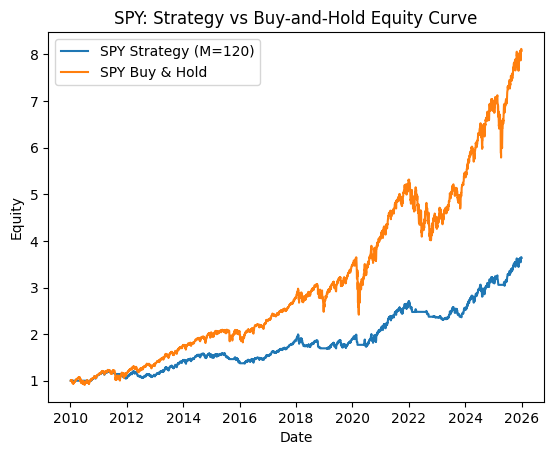

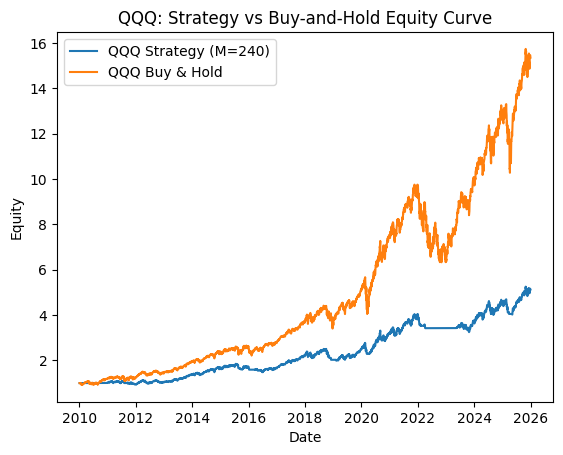

In [299]:
plt.figure
plt.plot(spy.index, spy["strategy_equity"], label="SPY Strategy (M=120)")
plt.plot(spy.index, spy["equity"], label="SPY Buy & Hold")
plt.title("SPY: Strategy vs Buy-and-Hold Equity Curve")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.legend()
plt.show()

plt.figure
plt.plot(qqq.index, qqq["strategy_equity"], label="QQQ Strategy (M=240)")
plt.plot(qqq.index, qqq["equity"], label="QQQ Buy & Hold")
plt.title("QQQ: Strategy vs Buy-and-Hold Equity Curve")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.legend()
plt.show()

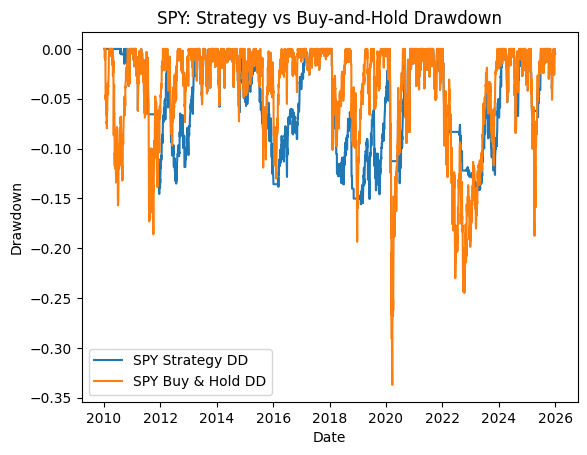

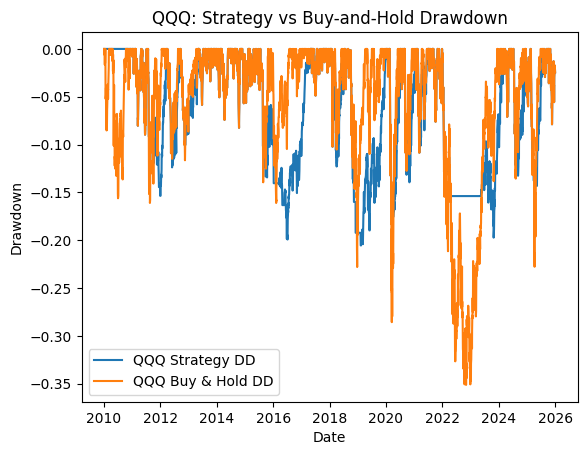

In [300]:
spy["strategy_dd"] = spy["strategy_equity"] / spy["strategy_equity"].cummax() - 1
qqq["strategy_dd"] = qqq["strategy_equity"] / qqq["strategy_equity"].cummax() - 1

plt.figure
plt.plot(spy.index, spy["strategy_dd"], label="SPY Strategy DD")
plt.plot(spy.index, spy["drawdown"], label="SPY Buy & Hold DD")
plt.title("SPY: Strategy vs Buy-and-Hold Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.show()

plt.figure
plt.plot(qqq.index, qqq["strategy_dd"], label="QQQ Strategy DD")
plt.plot(qqq.index, qqq["drawdown"], label="QQQ Buy & Hold DD")
plt.title("QQQ: Strategy vs Buy-and-Hold Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.show()

Overall, the strategy is more successful for SPY than for QQQ. It clearly improves downside-adjusted performance for SPY by substantially lowering maximum drawdown and increasing the Calmar ratio. However, QQQ sacrifices too much return to outperform buy-and-hold.

# Conclusion

This project evaluated a defensive trading overlay that combines a moving-average trend filter with an equity-curve drawdown control rule. The goal was to test whether this framework could reduce downside risk while maintaining acceptable long-run performance. The strategy was applied to SPY and QQQ using daily data, with the moving-average lookback optimized over a small grid and the drawdown thresholds, exposure reductions, and cooldown periods fixed by strategy design. Strategy performance was evaluated using annualized return, annualized volatility, Sharpe ratio, maximum drawdown, drawdown duration, and Calmar ratio.

Overall, the results provide strong support for the strategy's ability to reduce maximum drawdown, which was the main expected outcome. For both SPY and QQQ, the final strategy produced substantially smaller maximum drawdowns than buy-and-hold. This supports H1 and shows that the trend-filtered drawdown overlay is effective at reducing drawdown depth.




The evidence for H2 is more mixed. The strategy improved downside risk-adjusted performance for SPY. Although annualized return was lower than buy-and-hold, maximum drawdown fell sharply and the Calmar ratio increased from 0.41 to 0.54, This shows that the overlay successfully traded some upside performance for better downside-adjusted results.

The strategy also reduced volatility and maximum drawdown for QQQ, but the reduction in return was larger, Calmar ratio was slightly below buy-and-hold. Thus, the hypothesis that downside-adjusted performance would improve is supported more clearly for SPY than for QQQ.

The results do not support H3. Although the strategy reduced drawdown severity, it did not shorten drawdown duration. In both SPY and QQQ, drawdown duration was actually longer under the strategy than under buy-and-hold.

The evidence for H4 is supportive. Out-of-sample testing showed that the selected parameters remained reasonably effective outside the in-sample period, and the walk-forward analysis did not reveal severe performance collapse. In particular, QQQ showed strong stability in its preferred parameter choice across walk-forward windows, while SPY suggested a broader stable region rather than a single optimum.

In summary, this project shows that a trend-filtered drawdown control overlay can be a useful defensive strategy, especially for reducing maximum drawdown. The strategy was more successful for SPY than for QQQ, and its main strength was improving drawdown depth rather than drawdown duration. More broadly, the results suggest that simple risk-control overlays can add value when the objective is capital preservation, but their benefits depend on the asset and on the tradeoff between downside protection and long-run return.

# Extension

This extension applies the same trend-filtered drawdown-control strategy to a broader set of asset classes, including emerging market equities, small-cap U.S. equities, long-duration Treasury bonds, gold, and Bitcoin. This extension applies the same trend-filtered drawdown-control strategy to a broader set of asset classes, including emerging market equities, small-cap U.S. equities, long-duration Treasury bonds, gold, and Bitcoin.

In [301]:
extension_tickers = ["EEM", "IWM", "TLT", "GLD", "BTC-USD"]

ext_prices = yf.download(
    extension_tickers,
    start="2010-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)["Close"].dropna(how="all")

ext_prices.tail()

Ticker,BTC-USD,EEM,GLD,IWM,TLT
Date,,,,,
2025-12-26,87301.429688,54.799999,416.739990,251.419998,87.115982
2025-12-27,87802.156250,NaN,NaN,NaN,NaN
2025-12-28,87835.835938,NaN,NaN,NaN,NaN
2025-12-29,87138.140625,54.660000,398.600006,249.880005,87.443649
2025-12-30,88430.132812,54.880001,398.890015,248.029999,87.235130


In [302]:
extension_data = {}

for ticker in extension_tickers:
    temp = build_signals(ext_prices[ticker].dropna())
    extension_data[ticker] = temp

In [303]:
extension_opt_results = {}
for ticker in extension_tickers:
    extension_opt_results[ticker] = optimize_M(
        extension_data[ticker],
        start=insample_start,
        end=insample_end
    )


for ticker in extension_tickers:
    print(f"{ticker} In-Sample Parameter Optimization")
    display(extension_opt_results[ticker])

EEM In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,-0.022647,0.092264,-0.312449,1933.0,-0.245457,-0.072482
1,120.0,-0.023016,0.086046,-0.272994,2010.0,-0.267490,-0.084311
2,60.0,-0.043661,0.077232,-0.356323,2010.0,-0.565316,-0.122531


IWM In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.073801,0.131759,-0.201529,505.0,0.560120,0.366204
1,120.0,0.055631,0.122089,-0.170550,743.0,0.455658,0.326184
2,60.0,0.036857,0.112785,-0.194992,1159.0,0.326786,0.189016


TLT In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,120.0,0.034643,0.101266,-0.173833,986.0,0.342104,0.199291
1,60.0,0.036739,0.098599,-0.225665,986.0,0.372614,0.162805
2,240.0,0.014337,0.106234,-0.249984,986.0,0.134961,0.057353


GLD In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,60.0,0.021609,0.067698,-0.257262,1851.0,0.319195,0.083995
1,120.0,0.016014,0.071717,-0.210416,1851.0,0.223294,0.076106
2,240.0,0.004465,0.072833,-0.235365,1851.0,0.061311,0.018973


BTC-USD In-Sample Parameter Optimization


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.423036,0.320152,-0.278761,389.0,1.321359,1.517557
1,120.0,0.406286,0.319085,-0.278761,389.0,1.273286,1.457470
2,60.0,0.355792,0.323206,-0.333335,389.0,1.100822,1.067372


In [304]:
best_M_by_asset = {}

for ticker in extension_tickers:
    best_M_by_asset[ticker] = int(extension_opt_results[ticker].iloc[0]["M"])

best_M_by_asset

{'EEM': 240, 'IWM': 240, 'TLT': 120, 'GLD': 60, 'BTC-USD': 240}

In [305]:
extension_oos_results = {}

for ticker in extension_tickers:
    best_M = best_M_by_asset[ticker]
    extension_oos_results[ticker] = test_selected_M(
        extension_data[ticker],
        best_M,
        start=oos_start,
        end=oos_end
    )

for ticker in extension_tickers:
    print(f"{ticker} Out-of-Sample Test")
    display(extension_oos_results[ticker])

EEM Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.017768,0.081638,-0.207052,1223.0,0.217648,0.085816


IWM Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.034024,0.130027,-0.198808,1039.0,0.261668,0.171139


TLT Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,120.0,0.016311,0.074932,-0.169444,1461.0,0.217683,0.096265


GLD Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,60.0,0.077379,0.114057,-0.215422,1038.0,0.678421,0.359195


BTC-USD Out-of-Sample Test


,M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,240.0,0.01796,0.175667,-0.585588,1773.0,0.102236,0.030669


In [306]:
extension_wf = {}

for ticker in extension_tickers:
    extension_wf[ticker] = walk_forward(extension_data[ticker])

for ticker in extension_tickers:
    print(f"{ticker} Walk-Forward Analysis")
    display(extension_wf[ticker])

EEM Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,120,-0.027365,0.041075,-0.088238,425.0,-0.666234,-0.310130
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,120,0.030524,0.109339,-0.205041,235.0,0.279165,0.148866
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,240,0.032494,0.087395,-0.109236,238.0,0.371812,0.297470
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,240,-0.036203,0.101656,-0.166614,473.0,-0.356135,-0.217287
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,240,-0.014421,0.017905,-0.038570,93.0,-0.805439,-0.373904


IWM Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,120,0.061386,0.105080,-0.111959,359.0,0.584187,0.548295
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,240,0.075586,0.122967,-0.096621,84.0,0.614686,0.782295
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,240,0.055932,0.120791,-0.160695,433.0,0.463051,0.348066
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,60,-0.057323,0.122254,-0.266480,455.0,-0.468884,-0.215112
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,240,0.007515,0.108137,-0.090294,272.0,0.069498,0.083231


TLT Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,60,-0.039019,0.100189,-0.225665,485.0,-0.389451,-0.172905
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,120,-0.017307,0.047820,-0.087011,332.0,-0.361917,-0.198906
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,120,0.073754,0.134369,-0.148885,207.0,0.548890,0.495373
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,240,-0.036835,0.034395,-0.072314,368.0,-1.070942,-0.509382
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,60,0.000000,0.000000,0.000000,0.0,NaN,NaN


GLD Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2010-01-04,2015-01-03,2015-01-04,2017-01-03,60,0.000000,0.000000,0.000000,0.0,NaN,NaN
1,2012-01-04,2017-01-03,2017-01-04,2019-01-03,240,0.000000,0.000000,0.000000,0.0,NaN,NaN
2,2014-01-04,2019-01-03,2019-01-04,2021-01-03,60,0.019629,0.080228,-0.125617,102.0,0.244670,0.156264
3,2016-01-04,2021-01-03,2021-01-04,2023-01-03,120,-0.056297,0.072071,-0.128229,502.0,-0.781142,-0.439037
4,2018-01-04,2023-01-03,2023-01-04,2025-01-03,60,0.077456,0.123078,-0.098831,211.0,0.629325,0.783726


BTC-USD Walk-Forward Analysis


,TrainStart,TrainEnd,TestStart,TestEnd,Selected_M,AnnReturn,AnnVol,MaxDD,MaxDD_Duration,Sharpe,Calmar
0,2014-09-17,2019-09-16,2019-09-17,2021-09-16,240,0.198814,0.214950,-0.267468,207.0,0.924931,0.743317
1,2016-09-17,2021-09-16,2021-09-17,2023-09-16,120,-0.018682,0.092252,-0.143287,677.0,-0.202510,-0.130381
2,2018-09-17,2023-09-16,2023-09-17,2025-09-16,120,-0.007258,0.224379,-0.387346,277.0,-0.032346,-0.018737


In [307]:
extension_wf_summary = {}

for ticker in extension_tickers:
    extension_wf_summary[ticker] = summarize_walk_forward(extension_wf[ticker])

for ticker in extension_tickers:
    print(f"{ticker} Walk-Forward Summary")
    display(extension_wf_summary[ticker])

EEM Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,-0.002994,0.071474,-0.12154,292.8,-0.235366,-0.090997


IWM Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,0.028619,0.115846,-0.14521,320.6,0.252508,0.309355


TLT Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,-0.003881,0.063355,-0.106775,278.4,-0.318355,-0.096455


GLD Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,0.008158,0.055075,-0.070535,163.0,0.030951,0.166984


BTC-USD Walk-Forward Summary


,Avg_AnnReturn,Avg_AnnVol,Avg_MaxDD,Avg_MaxDD_Duration,Avg_Sharpe,Avg_Calmar
0,0.057625,0.177194,-0.266034,387.0,0.230025,0.198066


The extension reveals that this defensive strategy did not apply to all assets. Its success is highly dependent on the underlying trend characteristics of the asset.

The latest Walk Forward window for Gold achieved a Calmar of 0.78, and the OOS Sharpe ratio doubled from 0.31 to 0.67. This proves the strategy's robustness for gold.

IWM and TLT offer some protection, but their OOS Calmar ratios remained below 0.2. The frequent jumping of optimal M in walk-forward tests shows a high risk of overfitting.

EEM's lack of long-term growth is not suitable for this strategy. BTC showed severe performance decay. Its in-sample metrics are perfect, but the Calmar ratio in the walk-forward results turned negative, which means extreme overfitting.  




In [308]:
extension_final_data = {}
extension_final_perf = {}

for ticker in extension_tickers:
    M = best_M_by_asset[ticker]
    temp = extension_data[ticker].copy()
    temp = build_rule_with_cooldown(temp, M)
    temp = add_strategy_returns(temp, M)

    extension_final_data[ticker] = temp
    extension_final_perf[ticker] = performance_table(temp)
for ticker in extension_tickers:
    M = best_M_by_asset[ticker]
    print(f"{ticker} Final Strategy Performance (M={M})")
    display(extension_final_perf[ticker])

EEM Final Strategy Performance (M=240)


,Strategy,B&H
AnnReturn,-0.003822,0.037799
AnnVol,0.084854,0.213002
Sharpe,-0.045047,0.177457
MaxDD,-0.312449,-0.398223
MaxDD_Duration,3692.000000,1580.000000
Calmar,-0.012234,0.094918


IWM Final Strategy Performance (M=240)


,Strategy,B&H
AnnReturn,0.051766,0.103535
AnnVol,0.127014,0.223017
Sharpe,0.407558,0.464248
MaxDD,-0.234093,-0.411333
MaxDD_Duration,1039.000000,752.000000
Calmar,0.221132,0.251707


TLT Final Strategy Performance (M=120)


,Strategy,B&H
AnnReturn,0.024694,0.027742
AnnVol,0.090702,0.150972
Sharpe,0.272257,0.183759
MaxDD,-0.173833,-0.483512
MaxDD_Duration,1461.000000,1358.000000
Calmar,0.142057,0.057377


GLD Final Strategy Performance (M=60)


,Strategy,B&H
AnnReturn,0.044302,0.084162
AnnVol,0.095162,0.158178
Sharpe,0.465543,0.532068
MaxDD,-0.314987,-0.455550
MaxDD_Duration,3432.000000,2247.000000
Calmar,0.140647,0.184747


BTC-USD Final Strategy Performance (M=240)


,Strategy,B&H
AnnReturn,0.132772,0.379571
AnnVol,0.228600,0.558514
Sharpe,0.580805,0.679608
MaxDD,-0.585588,-0.833990
MaxDD_Duration,1773.000000,1079.000000
Calmar,0.226733,0.455126


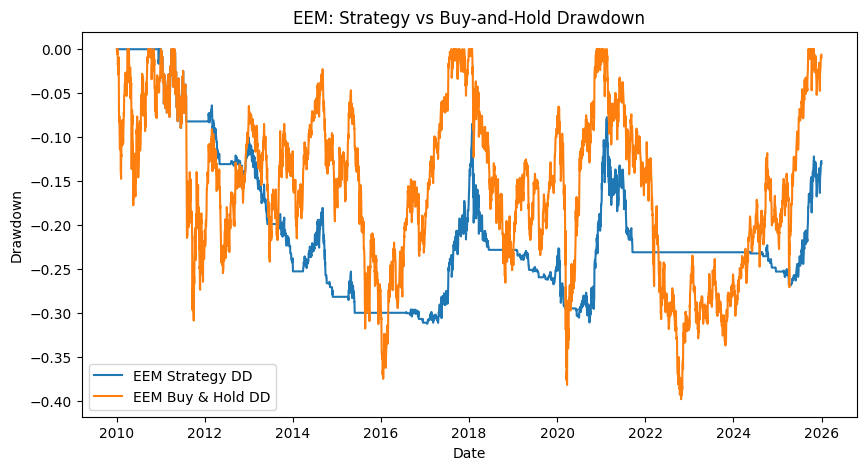

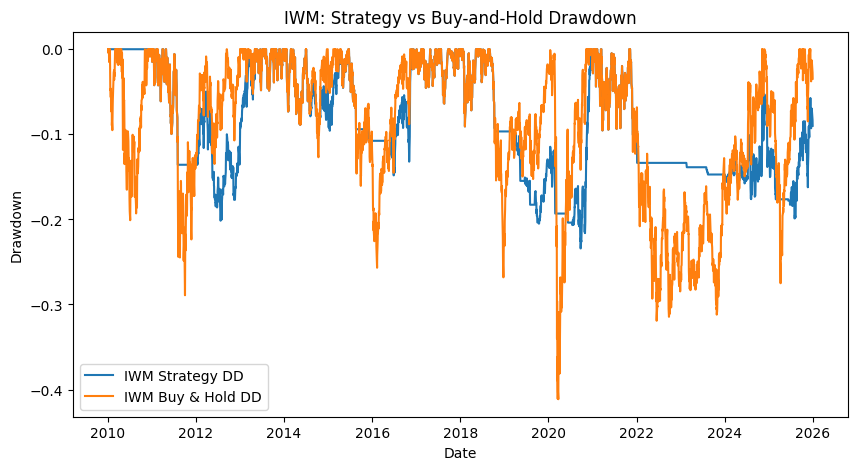

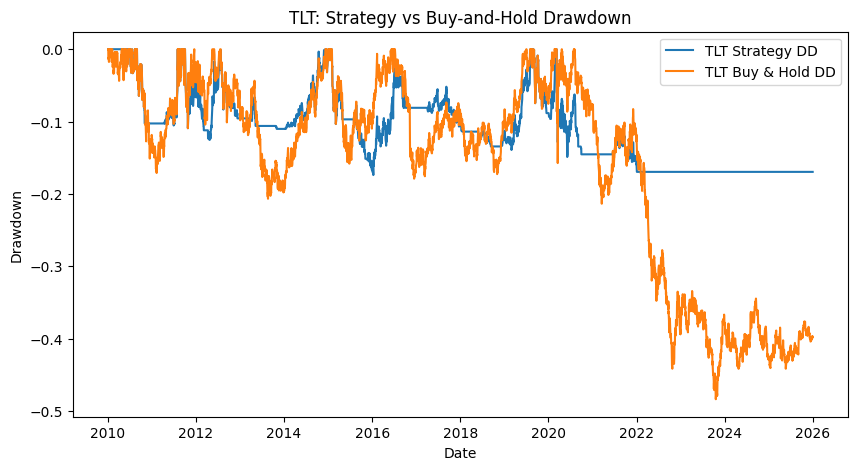

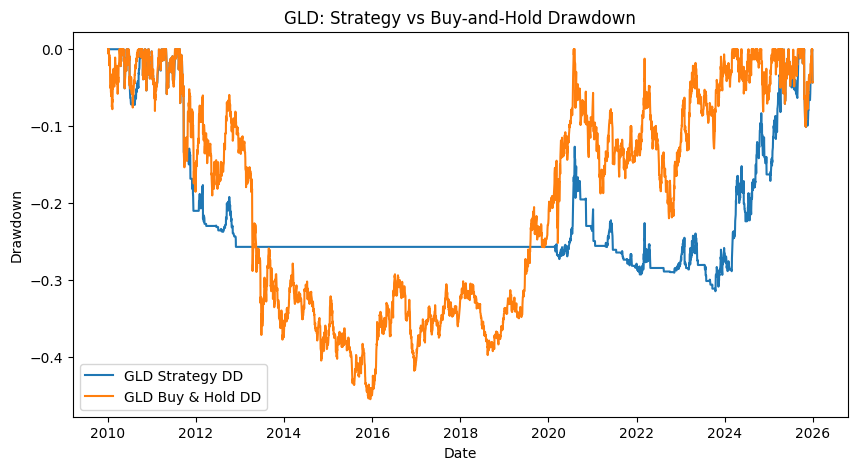

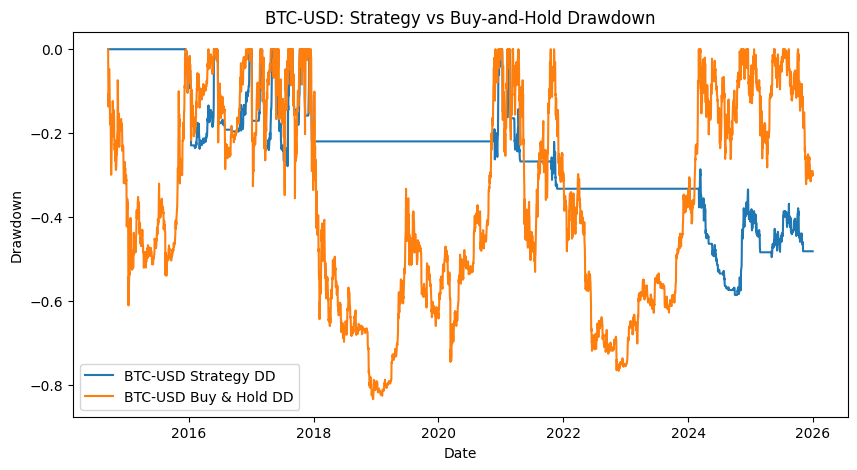

In [309]:
for ticker in extension_tickers:
    temp = extension_final_data[ticker].copy()
    temp["strategy_dd"] = temp["strategy_equity"] / temp["strategy_equity"].cummax() - 1

    plt.figure(figsize=(10, 5))
    plt.plot(temp.index, temp["strategy_dd"], label=f"{ticker} Strategy DD")
    plt.plot(temp.index, temp["drawdown"], label=f"{ticker} Buy & Hold DD")
    plt.title(f"{ticker}: Strategy vs Buy-and-Hold Drawdown")
    plt.ylabel("Drawdown")
    plt.xlabel("Date")
    plt.legend()
    plt.show()

Across all analyzed assets, the defensive strategy successfully reduces maximum drawdowns by 40% to 50% and significantly improves the Calmar Ratio for SPY, QQQ, and TLT, which achieves the goal of the strategy. However, this protection comes at the cost of signal lag, particularly in highly volatile or structurally weak assets like BTC and EEM. The M signals lead to longer recovery periods and lower annual returns compared to buy-and-hold. In conclusion, the strategy is a reasonable risk management tool for SPY and QQQ but is less efficient for other assets.